# A zoo of modified-gravity models: growth, lensing and degeneracies

**Cosmology lecture — companion notebook**

In this notebook, we propose to compare the growth rate for different gravity theories as $\Lambda$-CDM, $f(R)$ and DGP. These models will be explained in later lectures so fell free to come back to simply accept the equations or return to it later. Here we build a *framework* in which any number of models can be added, compared and confronted with the observables of the lecture. All is done using python and scipy integration functions. A similar notebook using the Boltzmann solver MGCAMB to do a comparable plot is available in the tutorial folder.

## The unifying idea

Everything a linear-perturbation observable can know about a gravity theory is contained in **three
functions**: the expansion history and the two modifications of the Poisson equations derived in the lecture,

$$k^2\Psi = -4\pi G a^2\,\mu(a,k)\,\bar\rho\Delta, \qquad \eta(a,k) \equiv \frac{\Phi}{\Psi},
\qquad \Sigma \equiv \frac{\mu\,(1+\eta)}{2},$$

with $\mu = \eta = \Sigma = 1$ in GR. To these functions, one must add the background evolution encoded in $H(z)$. Their roles are cleanly separated:

| function | what it does | which probe sees it |
|---|---|---|
| $H(a)$ | expansion, Hubble friction | SN, BAO, cosmic chronometers |
| $\mu(a,k)$ | force on **matter** | RSD / growth rate $f\sigma_8$ |
| $\Sigma(a,k)$ | deflection of **light** (Weyl potential) | weak lensing, CMB lensing, ISW |
| $\gamma(a,k)$ | gravitational slip | only via $\mu$ *vs* $\Sigma$ |

A model is therefore just a triple $\{H, \mu, \eta\}$ — which is exactly how we will encode it in code.

## Models included

| model | background | $\mu$ | scale-dep.? | one-line physics |
|---|---|---|---|---|
| $\Lambda$-CDM | $\Lambda$-CDM | 1 | — | reference |
| $w_0w_a$-CDM | $w_0w_a$ | 1 | no | GR with different expansion — the *degeneracy* benchmark |
| $f(R)$ Hu–Sawicki | $\simeq\Lambda$-CDM | $1\to4/3$ | **yes** | massive scalaron, Compton wavelength $1/M(a)$ |
| DGP (self-acc.) | DGP | $<1$ | no | brane-bending scalar, ghost branch |
| nDGP (normal) | $\Lambda$-CDM | $>1$ | no | same scalar, healthy branch, DE added by hand |
| Brans–Dicke | $\simeq \Lambda$-CDM | $\frac{1}{\overline{\phi}(a)}\frac{4+2\omega}{3+2\omega}$ | no | massless scalar — the theory of Lecture II |
| $\mu_0$–$\Sigma_0$ | $\Lambda$-CDM | $1+\mu_0\frac{\Omega_{\rm DE}(a)}{\Omega_{\rm DE,0}}$ | no | purely phenomenological (DES-style) |
| Linder $\gamma$ | $\Lambda$-CDM | — | no | $f\equiv\Omega_m(z)^\gamma$ by fiat |


## 1. Setup and framework

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Callable, Optional
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

Om0, h    = 0.28, 0.70          # matter density, reduced Hubble
SIGMA8_0  = 0.81                # sigma8 of the LCDM reference today
Z         = np.linspace(0.0, 1.5, 121)

# ---------- generic background equations for modified cosmologies ----------

def E_of_w0wa(w0=-1.0, wa=0.0, Om=Om0):
    """E(a) = H/H0 for (w0,wa)CDM; reduces to LCDM for w0=-1, wa=0."""
    return lambda a: np.sqrt(Om*a**-3 + (1-Om)*a**(-3*(1+w0+wa))*np.exp(-3*wa*(1-a)))

def dlnE_numeric(E, eps=1e-5):
    """dlnE/dlna by centred differences - works for any E(a)."""
    return lambda a: (np.log(E(a*np.exp(eps))) - np.log(E(a*np.exp(-eps))))/(2*eps)

def E_DGP(a, Om=Om0):
    Orc = (1-Om)**2/4
    return np.sqrt(Om*a**-3 + Orc) + np.sqrt(Orc)

def dlnE_DGP(a, Om=Om0):
    Orc = (1-Om)**2/4; s = np.sqrt(Om*a**-3 + Orc)
    return (-1.5*Om*a**-3/s)/E_DGP(a, Om)

## 2. The model registry

Each model is a small object holding $E(a)$, $\mathrm{d}\ln E/\mathrm{d}\ln a$ and a function returning
$(\mu,\gamma)$. Adding a new theory means adding one entry — nothing else in the notebook changes.

A note on each $\mu$:

* **$f(R)$** (quasi-static, Hu–Sawicki): $x=(k/a)^2/M^2(a)$, $\mu=\frac{1+4x/3}{1+x}$,
  $\gamma=\frac{1+2x/3}{1+4x/3}$. The scalaron mass $M^2 = 1/(3f_{RR})$ grows steeply into the past, so the
  modification switches off at high $z$ — and switches on earlier for larger $k$.
* **DGP**: $\mu = 1+\frac{1}{3\beta}$ with
  $\beta = 1 \mp 2 r_c H\left(1+\frac{\dot H}{3H^2}\right)$ — minus for the self-accelerating branch
  ($\beta<0$, $\mu<1$, and the branch carries a ghost), plus for the normal branch ($\mu>1$).
* **Brans–Dicke**: here we keep the *evolution of the scalar*, because for BD it is not a small
  correction — it dominates. See the whole dedicated lecture on this model (cosmology part), to understand the following. Writing $\overline{\phi} \equiv G_0\phi$ (normalised to $\overline{\phi}=1$ today),

  $$\mu(a) = \frac{1}{\overline{\phi}(a)}\frac{4+2\omega}{3+2\omega},\qquad
    \gamma = \frac{1+\omega}{2+\omega},\qquad
    \Sigma(a) = \frac{1}{\overline{\phi}(a)} .$$

  Note that $\gamma$ is untouched ($\overline{\phi}$ cancels in the ratio) and that $\Sigma = 1/\overline{\phi}$ **exactly**,
  with no $\omega$ at all: light responds only to the instantaneous $G_{\rm eff}=1/\phi$.
  We obtain $\overline{\phi}(a)$ by integrating the Klein–Gordon equation on the $\Lambda$-CDM background,

  $$\overline{\phi}'' + \left(3 + \frac{{\rm d}\ln E}{{\rm d}N}\right)\overline{\phi}' = \frac{3\,\Omega_m(a)}{3+2\omega},
    \qquad N=\ln a,$$

  whose matter-era attractor is $\overline{\phi}\propto a^{2/(3+2\omega)}$ — in agreement with the exact
  Brans–Dicke solution $\phi\propto t^{2/(4+3\omega)}$ to $\mathcal{O}(\omega^{-2})$. Since
  $\mathcal{T}=0$ for radiation, $\phi$ is frozen before equality, so starting on this attractor at
  $a_i=10^{-3}$ is the physically correct initial condition. The exact BD background *does* have a closed form,
  $a\propto t^{(2+2\omega)/(4+3\omega)}$, but it has no dark energy — it is Einstein–de Sitter with a
  $1/\omega$ tweak, and using it would replace a modified-gravity comparison by a
  $\Lambda$CDM-versus-EdS one. We therefore use a **designer** model: BD with $\omega$, *plus whatever
  dark-energy component reproduces $\Lambda$CDM expansion*. The background is then $\Lambda$CDM **by
  construction** rather than by neglect, exactly as for Hu–Sawicki $f(R)$ and nDGP, and $\overline{\phi}(a)$
  follows with no further approximation.
  $\omega\to\infty$ recovers GR, and $\omega=0$ gives $\mu=4/3$, $\gamma=1/2$ — the massless limit of $f(R)$.
  Solar-System tests require $\omega \gtrsim 4\times10^4$ *unscreened* (Cassini), so a cosmologically
  interesting BD needs screening: we use $\omega=100$ here purely for illustration.

In [30]:
@dataclass
class Model:
    name:   str
    color:  str
    E:      Callable                     # E(a)
    dlnE:   Callable                     # dlnE/dlna (a)
    mugam:  Callable                     # (a, k) -> (mu, gamma)
    k:      Optional[float] = None       # h/Mpc, for scale-dependent models
    ls:     str = "-"
    note:   str = ""

# ---------- mu, gamma for each theory ----------

def mg_GR(a, k):  return 1.0, 1.0

def mg_fR(a, k, fR0=1e-4, n=1.0, Om=Om0, hh=h):
    k_Mpc = k*hh;  H0 = 100*hh/299792.458
    R  = 3*H0**2*(Om*a**-3 + 4*(1-Om));  R0 = 3*H0**2*(Om + 4*(1-Om))
    M2 = 1/(3*(n+1)*fR0*R0**(n+1)/R**(n+2))       # scalaron mass^2
    x  = (k_Mpc/a)**2/M2
    return (1 + 4*x/3)/(1 + x), (1 + 2*x/3)/(1 + 4*x/3)

def _dgp_mugam(beta):
    mu = 1 + 1/(3*beta)
    return mu, (1 - 1/(3*beta))/(1 + 1/(3*beta))

def mg_sDGP(a, k, Om=Om0):
    beta = 1 - 2*(1/(1-Om))*E_DGP(a, Om)*(1 + dlnE_DGP(a, Om)/3)
    return _dgp_mugam(beta)

def mg_nDGP(a, k, Orc=0.25):
    EL   = np.sqrt(Om0*a**-3 + 1 - Om0)
    dlnE = -1.5*Om0*a**-3/(Om0*a**-3 + 1 - Om0)
    beta = 1 + 2*(1/(2*np.sqrt(Orc)))*EL*(1 + dlnE/3)
    return _dgp_mugam(beta)

def _BD_phi(w, Om=Om0, a_i=1e-3, npts=3000):
    """phi = G*phi(a) for Brans-Dicke on a (LCDM) background, normalised to phi(a=1)=1.
    Solves   phi'' + (3 + dlnE/dN) phi' = 3 Omega_m(a)/(3+2w)   in N = ln a,
    started on the matter-era attractor phi' = 2/(3+2w)  (phi is frozen before equality)."""
    E, dlnE = E_of_w0wa(Om=Om), dlnE_numeric(E_of_w0wa(Om=Om))
    def rhs(N, y):
        a = np.exp(N); phi, phip = y
        return [phip, -(3 + dlnE(a))*phip + 3*(Om*a**-3/E(a)**2)/(3 + 2*w)]
    N = np.linspace(np.log(a_i), 0.0, npts)
    s = solve_ivp(rhs, [N[0], 0.0], [1.0, 2/(3 + 2*w)], t_eval=N,
                  rtol=1e-10, atol=1e-14, method="DOP853")
    return N, s.y[0]/s.y[0][-1]

_BD_CACHE = {}
def mg_BD(a, k, w=100.0):
    """mu = (1/phi)(4+2w)/(3+2w),  gamma = (1+w)/(2+w),  hence Sigma = 1/phi exactly."""
    if w not in _BD_CACHE:
        _BD_CACHE[w] = _BD_phi(w)
    N, phi = _BD_CACHE[w]
    return (4 + 2*w)/(3 + 2*w)/np.interp(np.log(a), N, phi), (1 + w)/(2 + w)

def mg_BD_frozen(a, k, w=100.0):
    """The usual textbook approximation: phi held fixed. Kept for comparison."""
    return (4 + 2*w)/(3 + 2*w), (1 + w)/(2 + w)

def mg_muSigma(a, k, mu0=0.0, sig0=0.3, Om=Om0):
    fDE = (1/(Om*a**-3 + (1-Om)))            # = OmegaDE(a)/OmegaDE0 for LCDM
    mu, Sig = 1 + mu0*fDE, 1 + sig0*fDE
    return mu, 2*Sig/mu - 1                  # invert Sigma = mu(1+gamma)/2

# ---------- the zoo ----------
E_L, dE_L = E_of_w0wa(), dlnE_numeric(E_of_w0wa())
E_wa      = E_of_w0wa(-0.9, 0.3)

MODELS = [
 Model("$\\Lambda$CDM",            "black",  E_L,   dE_L,                    mg_GR,
       note="reference"),
 Model("$w_0w_a$CDM (-0.9, 0.3)",  "grey",   E_wa,  dlnE_numeric(E_wa),      mg_GR,  ls="--",
       note="GR, modified background"),
 Model("$f(R)$, $k=0.02$",         "red",    E_L,   dE_L,                    mg_fR,  k=0.02,
       note="|f_R0|=1e-4, n=1"),
 Model("$f(R)$, $k=0.1$",          "green",  E_L,   dE_L,                    mg_fR,  k=0.10,
       note="same model, smaller scale"),
 Model("DGP (self-acc.)",          "blue",   E_DGP, dlnE_DGP,                mg_sDGP,
       note="ghost branch, ruled out"),
 Model("nDGP ($\\Omega_{rc}=0.25$)","darkorange", E_L, dE_L,                 mg_nDGP,
       note="healthy branch"),
 Model("Brans-Dicke ($\\omega=100$)","purple", E_L, dE_L,                    mg_BD,  ls=":",
       note="designer BD: LCDM expansion + evolving phi"),
 Model("BD ($\\omega=100$), frozen $\\phi$","violet", E_L, dE_L,             mg_BD_frozen, ls=(0,(1,3)),
       note="same, but with the usual constant-mu approximation"),
 Model("$\\mu_0=0,\\ \\Sigma_0=0.3$","brown", E_L,  dE_L,                    mg_muSigma, ls="-.",
       note="lensing-only modification"),
]
print("\n".join(f"{m.name:32s} {m.note}" for m in MODELS))

$\Lambda$CDM                     reference
$w_0w_a$CDM (-0.9, 0.3)          GR, modified background
$f(R)$, $k=0.02$                 |f_R0|=1e-4, n=1
$f(R)$, $k=0.1$                  same model, smaller scale
DGP (self-acc.)                  ghost branch, ruled out
nDGP ($\Omega_{rc}=0.25$)        healthy branch
Brans-Dicke ($\omega=100$)       designer BD: LCDM expansion + evolving phi
BD ($\omega=100$), frozen $\phi$ same, but with the usual constant-mu approximation
$\mu_0=0,\ \Sigma_0=0.3$         lensing-only modification


## 3. Integrating the growth equation

One ODE for all models. Everything a linear-growth calculation needs is contained in the three
ingredients each `Model` carries — $E(a)$, ${\rm d}\ln E/{\rm d}\ln a$, and $\mu(a,k)$ — so a single
integrator serves the whole zoo.

### The equation

In the sub-horizon, quasi-static limit the matter density contrast $\Delta$ — the same $\Delta$ that
appears in the modified Poisson equation of §1 — obeys

$$\ddot\Delta + 2H\dot\Delta = 4\pi G\,\mu(a,k)\,\bar\rho_m\,\Delta .$$

Trading cosmic time for the number of e-folds $N = \ln a$ (so $\dot{} = H\,{\rm d}/{\rm d}N$ and
$\dot H = H^2\,{\rm d}\ln E/{\rm d}N$) and using
$\Omega_m(a) = 8\pi G\bar\rho_m/3H^2 = \Omega_{m,0}a^{-3}/E^2$, this becomes the dimensionless system
actually coded in `rhs`:

$$\boxed{\;\Delta'' + \left(2 + \frac{{\rm d}\ln E}{{\rm d}N}\right)\Delta'
\;=\; \frac{3}{2}\,\frac{\Omega_{m,0}\,a^{-3}}{E(a)^2}\;\mu(a,k)\;\Delta\;}$$

with $' = {\rm d}/{\rm d}N$ and the state vector $y = (\Delta, \Delta')$. Working in $\ln a$ is not
cosmetic: it removes $H_0$ and all units from the problem.

**Modified gravity enters in exactly one slot.** All of $f(R)$, DGP, BD and the rest reach the growth
equation only by multiplying the source term by $\mu$. More attraction ($\mu>1$) $\Rightarrow$ faster
growth; less ($\mu<1$) $\Rightarrow$ slower.

**The slip $\gamma$ does not appear at all.** Matter falls into $\Psi$ only, so clustering is blind to
$\gamma$; the slip shows up later in $\Sigma$, in lensing and in $E_G$. This is exactly why a
lensing-only modification can move $E_G$ *without touching growth*, and why the two observables are
complementary rather than redundant.

We start at $a_i = 10^{-3}$ — safely after matter–radiation equality, safely before $\Lambda$ — where
every model here reduces to Einstein–de Sitter, whose growing mode is $\Delta\propto a$. Setting

$$\Delta(a_i) = a_i, \qquad \Delta'(a_i) = a_i$$

enforces $\Delta' = \Delta$, i.e. ${\rm d}\ln\Delta/{\rm d}\ln a = 1$: this **selects the growing mode
and kills the decaying one** ($\Delta\propto a^{-3/2}$), which would otherwise contaminate the solution.

Crucially, the initial amplitude is *identical for every model*. That is a physical statement, not a
convention: it means all models share the same primordial spectrum, so the relative amplitudes of
$D(z)$ that come out are meaningful.

* `sol.y[0]` $= \Delta(N) \propto D(z)$, the growth **factor** (unnormalised);
* `sol.y[1]/sol.y[0]` $= \Delta'/\Delta = {\rm d}\ln D/{\rm d}\ln a = f(z)$, the growth **rate**.

Note that $f$ requires no numerical differentiation — it is just the ratio of the two state variables,
which is why it comes out as accurate as $D$ itself. The `[::-1]` slices exist only because `solve_ivp`
needs `t_eval` increasing in $N$, i.e. *decreasing* in $z$; they flip the arrays back into the ordering
of `Z`.

$D(z)$ is defined only up to an overall constant, so we fix it once:

$$\sigma_8^{\rm model}(0) = \sigma_8^{\rm ref}\;\frac{D^{\rm model}(0)}{D^{\Lambda{\rm CDM}}(0)},
\qquad \sigma_8^{\rm ref} = 0.81 .$$

In words: calibrate $\Lambda$-CDM to the observed $\sigma_8$ today, and then every other model's
$\sigma_8$ is **predicted rather than fitted**, because they all started from the same primordial
amplitude. A theory that grows structure faster ends up with both a larger $f$ *and* a larger
$\sigma_8$ — the two compound, which is why the $f\sigma_8$ ranking in §6 differs from the $f$ ranking
in §5.

In [31]:
def solve(model, zs=Z, a_i=1e-3):
    """Return D(z) (same initial amplitude for all models) and f(z)."""
    def rhs(N, y):
        a = np.exp(N); d, dp = y
        mu, _ = model.mugam(a, model.k)
        return [dp, -(2 + model.dlnE(a))*dp + 1.5*(Om0*a**-3/model.E(a)**2)*mu*d]
    Ne  = np.log(1/(1 + np.asarray(zs)))[::-1]
    sol = solve_ivp(rhs, [np.log(a_i), 0.0], [a_i, a_i], t_eval=Ne,
                    rtol=1e-10, atol=1e-14, method="DOP853")
    return sol.y[0][::-1], (sol.y[1]/sol.y[0])[::-1]

RES = {m.name: solve(m) for m in MODELS}
D_ref = RES["$\\Lambda$CDM"][0][0]           # LCDM D(z=0), used to normalise sigma8

print(f"{'model':32s} {'f(0)':>7s} {'f(1.5)':>8s} {'sigma8(0)':>10s}")
for m in MODELS:
    D, f = RES[m.name]
    print(f"{m.name:32s} {f[0]:7.4f} {f[-1]:8.4f} {SIGMA8_0*D[0]/D_ref:10.4f}")

model                               f(0)   f(1.5)  sigma8(0)
$\Lambda$CDM                      0.4932   0.9201     0.8100
$w_0w_a$CDM (-0.9, 0.3)           0.4895   0.8686     0.7507
$f(R)$, $k=0.02$                  0.5106   0.9274     0.8239
$f(R)$, $k=0.1$                   0.5693   0.9940     0.9016
DGP (self-acc.)                   0.4287   0.7908     0.6461
nDGP ($\Omega_{rc}=0.25$)         0.5252   0.9570     0.8671
Brans-Dicke ($\omega=100$)        0.4957   0.9281     0.9342
BD ($\omega=100$), frozen $\phi$  0.4947   0.9228     0.8251
$\mu_0=0,\ \Sigma_0=0.3$          0.4932   0.9201     0.8100


## 5. The generalized figure: growth rate $f(z)$

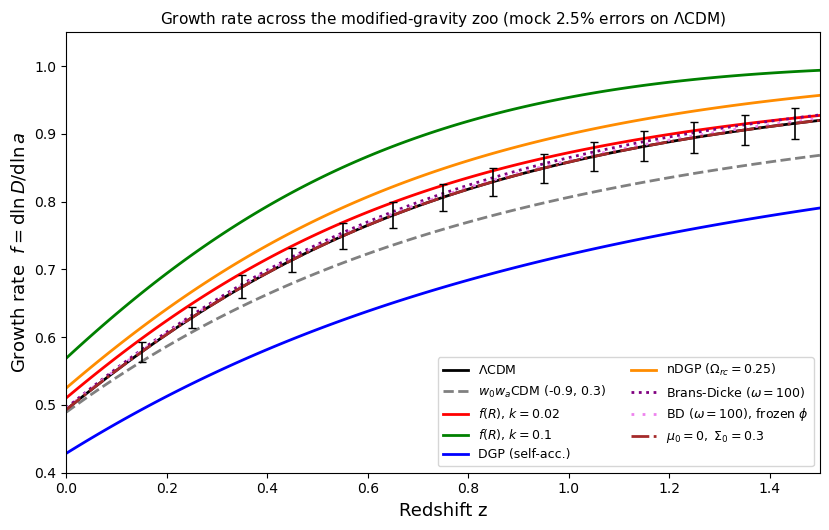

In [32]:
fig, ax = plt.subplots(figsize=(8.4, 5.4))
for m in MODELS:
    ax.plot(Z, RES[m.name][1], color=m.color, ls=m.ls, lw=2, label=m.name)

z_d = np.arange(0.15, 1.5, 0.1)
f_d = np.interp(z_d, Z, RES["$\\Lambda$CDM"][1])
ax.errorbar(z_d, f_d, yerr=0.025*f_d, fmt="none", ecolor="black", capsize=3, lw=1.2)

ax.set_xlim(0, 1.5); ax.set_ylim(0.4, 1.05)
ax.set_xlabel("Redshift z", fontsize=13)
ax.set_ylabel(r"Growth rate  $f = \mathrm{d}\ln D/\mathrm{d}\ln a$", fontsize=13)
ax.legend(fontsize=9, ncol=2, loc="lower right")
ax.set_title("Growth rate across the modified-gravity zoo (mock 2.5% errors on $\\Lambda$CDM)", fontsize=11)
plt.tight_layout(); 
plt.savefig("../pictures/growth_rate_modified_gravity_analytical.png", dpi=300)
plt.show()

## 6. What is actually measured: $f\sigma_8(z)$

RSD do not measure $f$: they measure the *amplitude* of the velocity power spectrum, $f\sigma_8(z)$, where
$\sigma_8(z) = \sigma_8^{\rm ref}\,D(z)/D_{\Lambda{\rm CDM}}(0)$ with a common primordial normalization.
This changes the ranking of models — a theory that grows structure faster has both larger $f$ *and* larger
$\sigma_8$, so the two effects compound. It also introduces the notorious degeneracy with the $S_8$ tension.

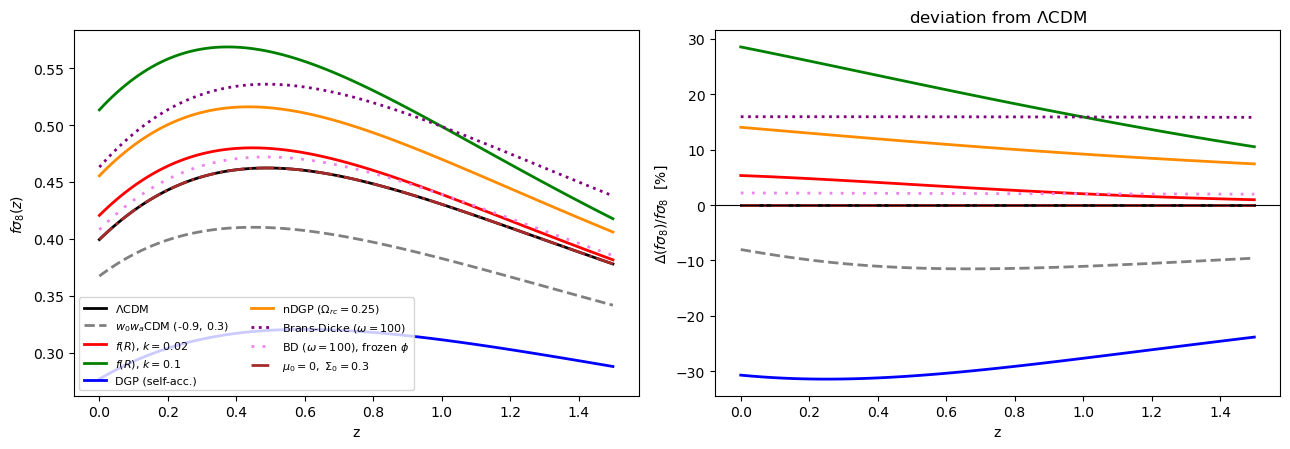

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for m in MODELS:
    D, f = RES[m.name]
    axes[0].plot(Z, f*SIGMA8_0*D/D_ref, color=m.color, ls=m.ls, lw=2, label=m.name)
    axes[1].plot(Z, 100*(f*D/(RES["$\\Lambda$CDM"][1]*RES["$\\Lambda$CDM"][0]) - 1),
                 color=m.color, ls=m.ls, lw=2)
axes[0].set_xlabel("z"); axes[0].set_ylabel(r"$f\sigma_8(z)$"); axes[0].legend(fontsize=8, ncol=2)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("z"); axes[1].set_ylabel(r"$\Delta(f\sigma_8)/f\sigma_8$  [%]")
axes[1].set_title("deviation from $\\Lambda$CDM")
plt.tight_layout(); plt.show()

## 7. Behind the curves: $\mu$, $\gamma$, $\Sigma$

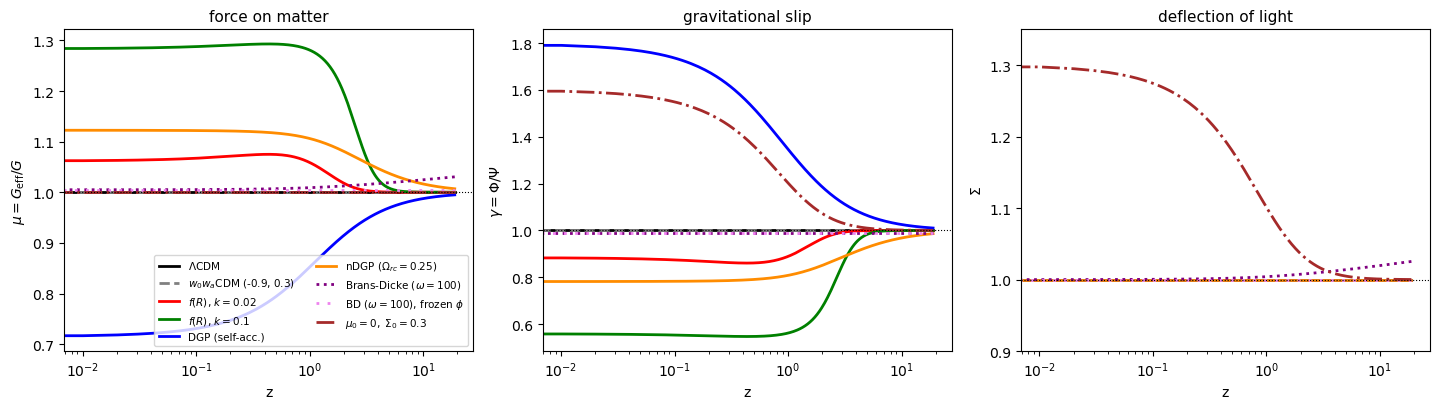

In [34]:
a_g = np.logspace(-1.3, 0, 300); z_g = 1/a_g - 1
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharex=True)
for m in MODELS:
    mg  = np.array([m.mugam(a, m.k) for a in a_g])
    mu, gam = mg[:, 0], mg[:, 1]
    axes[0].plot(z_g, mu,                 color=m.color, ls=m.ls, lw=2, label=m.name)
    axes[1].plot(z_g, gam,                color=m.color, ls=m.ls, lw=2)
    axes[2].plot(z_g, 0.5*mu*(1 + gam),   color=m.color, ls=m.ls, lw=2)
for ax, lab, ttl in zip(axes, [r"$\mu = G_{\rm eff}/G$", r"$\gamma = \Phi/\Psi$", r"$\Sigma$"],
                        ["force on matter", "gravitational slip", "deflection of light"]):
    ax.set_xscale("log"); ax.set_xlabel("z"); ax.set_ylabel(lab); ax.set_title(ttl, fontsize=11)
    ax.axhline(1, color="k", lw=0.8, ls=":")
axes[2].set_ylim(0.9, 1.35)
axes[0].legend(fontsize=7.5, ncol=2)
plt.tight_layout(); plt.show()

## 8. The cleanest discriminant: $E_G$

Recall from the lecture: $E_G$ takes the ratio of lensing to velocities around the *same* galaxies, so the
galaxy bias cancels. In terms of our functions,

$$E_G(z) = \frac{\Omega_{m,0}\,\Sigma(a,k)}{f(z)},$$

which reduces to $\Omega_{m,0}/f$ in GR. One checks algebraically that $\Sigma=1$ **exactly** for
$f(R)$, for both DGP branches, and for BD *at fixed* $\phi$ — so those models probe $E_G$ purely
through $f$, while the $\Sigma_0$ model moves $E_G$ *without touching growth at all*. Two very
different physical effects, one statistic: this is why $E_G$ is quoted as a null test of GR.

Brans–Dicke is the instructive exception once the scalar is allowed to evolve: $\Sigma = 1/\overline{\phi} \ne 1$,
because a drifting $G$ deflects light differently. It is the one scalar–tensor model here that moves
$E_G$ through *both* channels at once.

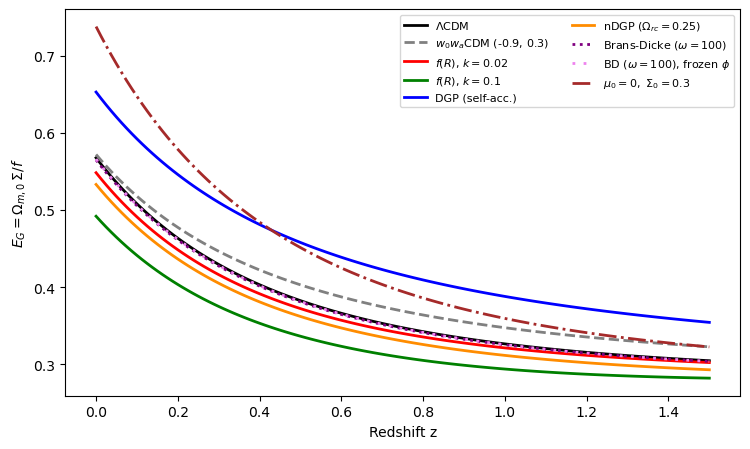

In [35]:
plt.figure(figsize=(7.6, 4.6))
for m in MODELS:
    f = RES[m.name][1]
    Sig = np.array([0.5*m.mugam(1/(1+z), m.k)[0]*(1 + m.mugam(1/(1+z), m.k)[1]) for z in Z])
    plt.plot(Z, Om0*Sig/f, color=m.color, ls=m.ls, lw=2, label=m.name)
plt.xlabel("Redshift z"); plt.ylabel(r"$E_G = \Omega_{m,0}\,\Sigma / f$")
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 9. The central question: what is *not* degenerate with dark energy?

A skeptic's objection to all of the above: any change in $f(z)$ could be mimicked by GR with a different
expansion history and a different $\Omega_m$. Let us test this honestly, by *fitting* a GR $w_0w_a$-CDM model
(free $\Omega_m,w_0,w_a$) to the growth history of each modified-gravity model.

The result below is the punchline of the whole lecture:

* **scale-independent** modifications (nDGP, DGP, BD) are mimicked to a fraction of a percent — they are
  effectively degenerate with dark energy as far as growth is concerned;
* **scale-dependent** $f(R)$ can be mimicked at *one* $k$ (~1%), but no single GR model fits *two* different
  $k$ simultaneously (~5–6% residual).

Since $H(a)$ is scale-independent by homogeneity, **scale dependence is the one signature that no dark-energy
model can fake**. That is the deepest reason cosmological tests of gravity target the $k$-dependence of growth.

In [36]:
def f_GR(zs, Om, w0, wa, a_i=1e-3):
    """Growth rate of a GR (w0,wa)CDM model - analytic dlnE for speed."""
    def rhs(N, y):
        a = np.exp(N); d, dp = y
        de   = (1-Om)*a**(-3*(1+w0+wa))*np.exp(-3*wa*(1-a))
        E2   = Om*a**-3 + de
        dlnE = 0.5*(-3*Om*a**-3 + de*(-3*(1+w0+wa) + 3*wa*a))/E2
        return [dp, -(2 + dlnE)*dp + 1.5*(Om*a**-3/E2)*d]
    Ne = np.log(1/(1 + np.asarray(zs)))[::-1]
    s  = solve_ivp(rhs, [np.log(a_i), 0], [a_i, a_i], t_eval=Ne,
                   rtol=1e-8, atol=1e-12, method="DOP853")
    return (s.y[1]/s.y[0])[::-1]

zf = np.linspace(0, 1.5, 21)
def best_GR(targets):
    """Fit one GR model (Om, w0, wa) to a list of target f(z) curves simultaneously."""
    cost = lambda p: sum(np.sum((f_GR(zf, *p) - t)**2) for t in targets)
    r = minimize(cost, [0.30, -1.05, 0.05], method="Nelder-Mead",
                 options={"maxiter": 600, "fatol": 1e-12, "xatol": 1e-4})
    return r.x, f_GR(zf, *r.x)

print(f"{'target':28s} {'Om_fit':>7s} {'w0':>7s} {'wa':>7s} {'max resid':>10s}")
for m in MODELS[2:]:                       # skip LCDM and w0waCDM themselves
    tgt = np.interp(zf, Z, RES[m.name][1])
    p, fit = best_GR([tgt])
    print(f"{m.name:28s} {p[0]:7.3f} {p[1]:7.3f} {p[2]:7.3f} {100*np.max(np.abs(fit/tgt-1)):9.2f}%")

# the decisive test: fit BOTH f(R) wavenumbers with ONE GR model
t_red   = np.interp(zf, Z, RES["$f(R)$, $k=0.02$"][1])
t_green = np.interp(zf, Z, RES["$f(R)$, $k=0.1$"][1])
p, fit  = best_GR([t_red, t_green])
print(f"\nOne GR model forced to fit BOTH f(R) wavenumbers: Om={p[0]:.3f}, w0={p[1]:.3f}, wa={p[2]:.3f}")
print(f"   residual vs k=0.02: {100*np.max(np.abs(fit/t_red-1)):.2f}%")
print(f"   residual vs k=0.10: {100*np.max(np.abs(fit/t_green-1)):.2f}%")
print("   -> scale dependence cannot be absorbed into the expansion history.")

target                        Om_fit      w0      wa  max resid
$f(R)$, $k=0.02$               0.296  -1.050   0.102      0.16%
$f(R)$, $k=0.1$                0.365  -0.869  -1.935      1.08%
DGP (self-acc.)                0.225  -0.810   0.347      0.05%
nDGP ($\Omega_{rc}=0.25$)      0.314  -0.959  -0.569      0.45%
Brans-Dicke ($\omega=100$)     0.283  -0.982  -0.141      0.16%
BD ($\omega=100$), frozen $\phi$   0.282  -0.996  -0.040      0.04%
$\mu_0=0,\ \Sigma_0=0.3$       0.280  -1.000   0.000      0.00%

One GR model forced to fit BOTH f(R) wavenumbers: Om=0.328, w0=-1.022, wa=-0.499
   residual vs k=0.02: 5.94%
   residual vs k=0.10: 5.17%
   -> scale dependence cannot be absorbed into the expansion history.
